In [3]:
import pandas as pd
import numpy as np

print("Pandas version:", pd.__version__)
print("NumPy version:", np.__version__)

Pandas version: 3.0.6
NumPy version: 2.5.3


In [4]:
import pandas as pd

df = pd.read_csv("D:\\retail_inventory_management\\data\\retail_inventory_management_dataset.csv")

df.head()

,Date,Store_ID,City,Product_ID,Product_Name,Product_Category,Supplier,Unit_Price,Discount_Percent,Units_Sold,Revenue,Stock_Level,Reorder_Level,Lead_Time_Days,Low_Stock
0,2024-01-01,S004,Lucknow,P006,Bluetooth Speaker,Electronics,Supplier A,2955.40,5.0,5,14038.15,141,72,3,False
1,2024-01-01,S005,Jaipur,P007,Smart Watch,Wearables,Supplier D,4608.45,5.0,7,30646.19,142,61,11,False
2,2024-01-01,S001,Delhi,P012,Backpack,Travel,Supplier A,1832.89,5.0,15,26118.68,333,150,5,False
3,2024-01-01,S004,Lucknow,P005,Power Bank,Electronics,Supplier D,1577.72,15.0,17,22798.05,271,144,8,False
4,2024-01-01,S003,Ghaziabad,P007,Smart Watch,Wearables,Supplier D,4743.97,5.0,13,58588.03,166,68,2,False


In [5]:
df.shape

(15000, 15)

In [6]:
df.columns

Index(['Date', 'Store_ID', 'City', 'Product_ID', 'Product_Name',
       'Product_Category', 'Supplier', 'Unit_Price', 'Discount_Percent',
       'Units_Sold', 'Revenue', 'Stock_Level', 'Reorder_Level',
       'Lead_Time_Days', 'Low_Stock'],
      dtype='str')

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Date              15000 non-null  str    
 1   Store_ID          15000 non-null  str    
 2   City              15000 non-null  str    
 3   Product_ID        15000 non-null  str    
 4   Product_Name      15000 non-null  str    
 5   Product_Category  15000 non-null  str    
 6   Supplier          14970 non-null  str    
 7   Unit_Price        15000 non-null  float64
 8   Discount_Percent  14970 non-null  float64
 9   Units_Sold        15000 non-null  int64  
 10  Revenue           15000 non-null  float64
 11  Stock_Level       15000 non-null  int64  
 12  Reorder_Level     15000 non-null  int64  
 13  Lead_Time_Days    15000 non-null  int64  
 14  Low_Stock         15000 non-null  bool   
dtypes: bool(1), float64(3), int64(4), str(7)
memory usage: 2.4 MB


In [8]:
df.describe()

,Unit_Price,Discount_Percent,Units_Sold,Revenue,Stock_Level,Reorder_Level,Lead_Time_Days
count,15000.000000,14970.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,2347.355377,6.552438,17.719533,29355.042051,232.123867,124.152333,7.950733
std,1915.935403,6.214330,9.203383,13417.859034,116.550333,53.741381,3.744174
min,644.000000,0.000000,1.000000,4025.170000,0.000000,35.000000,2.000000
25%,1216.390000,0.000000,11.000000,20201.777500,149.000000,86.000000,5.000000
50%,1753.410000,5.000000,16.000000,26508.145000,212.500000,115.000000,8.000000
75%,2662.590000,10.000000,23.000000,35372.107500,292.250000,152.000000,11.000000
max,9173.490000,20.000000,67.000000,154956.620000,816.000000,300.000000,14.000000


In [9]:
df.isnull().sum()

Date                 0
Store_ID             0
City                 0
Product_ID           0
Product_Name         0
Product_Category     0
Supplier            30
Unit_Price           0
Discount_Percent    30
Units_Sold           0
Revenue              0
Stock_Level          0
Reorder_Level        0
Lead_Time_Days       0
Low_Stock            0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df = df.drop_duplicates()

In [12]:
df["Date"] = pd.to_datetime(df["Date"])

In [13]:
df.dtypes

Date                datetime64[us]
Store_ID                       str
City                           str
Product_ID                     str
Product_Name                   str
Product_Category               str
Supplier                       str
Unit_Price                 float64
Discount_Percent           float64
Units_Sold                   int64
Revenue                    float64
Stock_Level                  int64
Reorder_Level                int64
Lead_Time_Days               int64
Low_Stock                     bool
dtype: object

In [14]:
df["Revenue"] = df["Units_Sold"] * df["Unit_Price"]

In [15]:
df["Month"] = df["Date"].dt.month

In [16]:
df["Year"] = df["Date"].dt.year

In [17]:
df["Day"] = df["Date"].dt.day

In [18]:
df["DayOfWeek"] = df["Date"].dt.dayofweek

In [19]:
total_revenue = df["Revenue"].sum()

print("Total Revenue:", total_revenue)

Total Revenue: 473196291.33000004


In [20]:
total_units = df["Units_Sold"].sum()

print("Total Units Sold:", total_units)

Total Units Sold: 265793


In [21]:
top_products = (
    df.groupby("Product_Name")["Units_Sold"]
    .sum()
    .sort_values(ascending=False)
)

top_products.head(10)

Product_Name
Water Bottle      35829
Wireless Mouse    30024
Power Bank        23045
Travel Adapter    21034
Yoga Mat          19921
Laptop Bag        19601
Desk Lamp         17996
Backpack          16982
USB-C Hub         15742
Fitness Band      13746
Name: Units_Sold, dtype: int64

In [22]:
category_sales = (
    df.groupby("Product_Category")["Revenue"]
    .sum()
    .sort_values(ascending=False)
)

category_sales

Product_Category
Electronics    95534332.68
Sports         92442413.22
Accessories    79858527.37
Wearables      74005372.54
Travel         55441094.35
Furniture      52481087.39
Home           23433463.78
Name: Revenue, dtype: float64

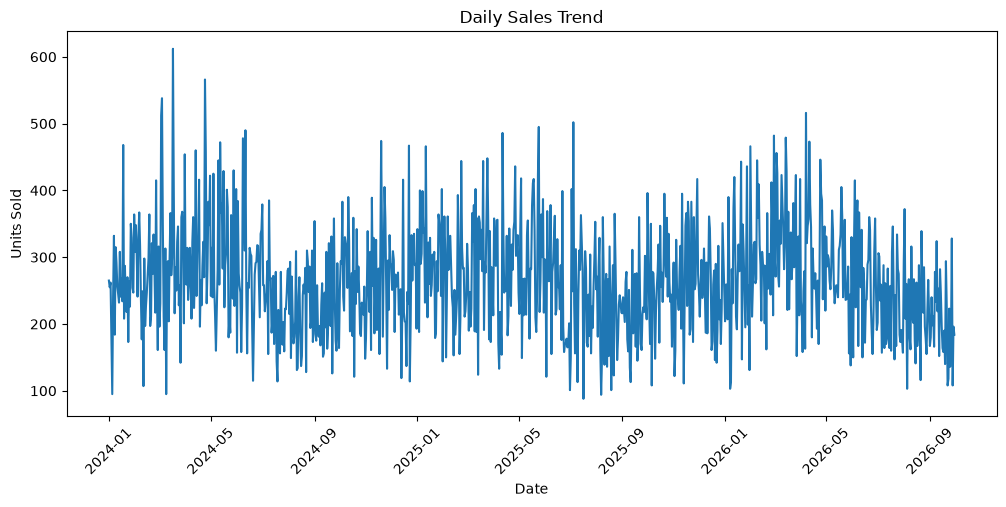

In [23]:
import matplotlib.pyplot as plt

daily_sales = df.groupby("Date")["Units_Sold"].sum()

plt.figure(figsize=(12, 5))
plt.plot(daily_sales)
plt.title("Daily Sales Trend")
plt.xlabel("Date")
plt.ylabel("Units Sold")
plt.xticks(rotation=45)
plt.show()

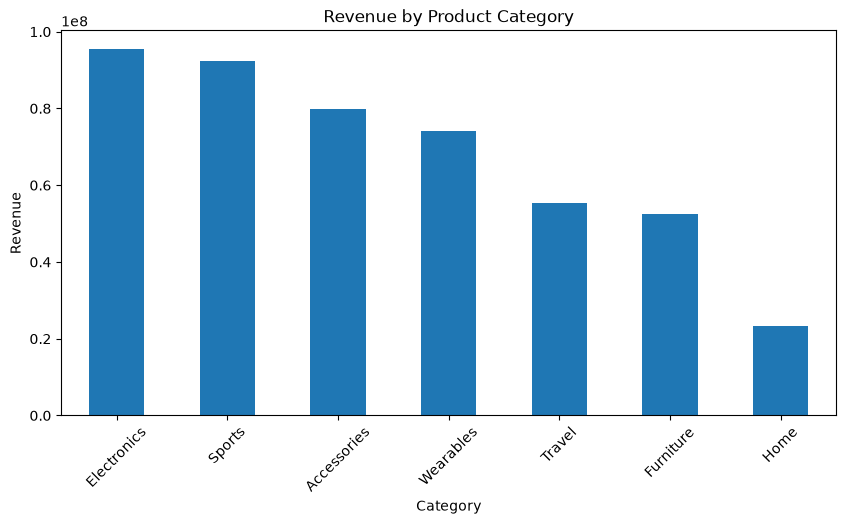

In [24]:
category_sales.plot(kind="bar", figsize=(10, 5))

plt.title("Revenue by Product Category")
plt.xlabel("Category")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

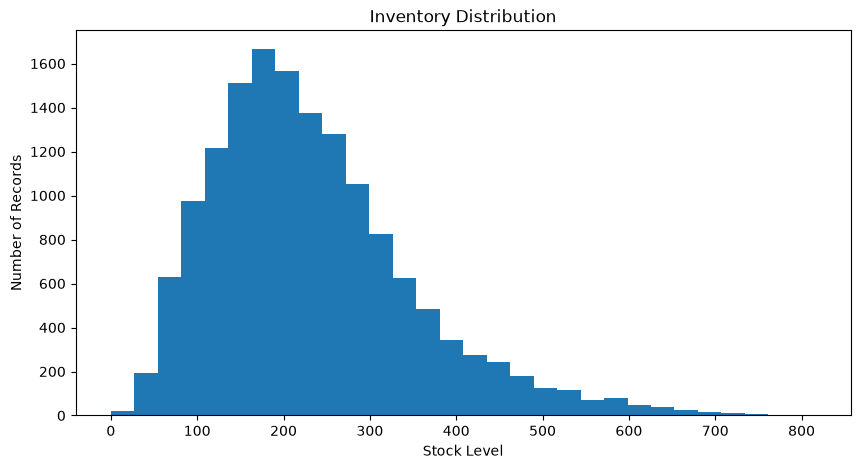

In [25]:
plt.figure(figsize=(10, 5))

plt.hist(df["Stock_Level"], bins=30)

plt.title("Inventory Distribution")
plt.xlabel("Stock Level")
plt.ylabel("Number of Records")

plt.show()

In [26]:
df["Low_Stock"] = df["Stock_Level"] <= df["Reorder_Level"]

In [27]:
df["Low_Stock"].value_counts()

Low_Stock
False    14515
True       485
Name: count, dtype: int64

In [28]:
low_stock = df[df["Low_Stock"] == True]

low_stock.head()

,Date,Store_ID,City,Product_ID,Product_Name,Product_Category,Supplier,Unit_Price,Discount_Percent,Units_Sold,Revenue,Stock_Level,Reorder_Level,Lead_Time_Days,Low_Stock,Month,Year,Day,DayOfWeek
14,2024-01-02,S005,Jaipur,P004,USB-C Hub,Electronics,Supplier A,1684.60,10.0,11,18530.60,96,102,14,True,1,2024,2,1
35,2024-01-03,S004,Lucknow,P012,Backpack,Travel,Supplier D,1763.72,0.0,11,19400.92,61,108,13,True,1,2024,3,2
43,2024-01-03,S005,Jaipur,P013,Travel Adapter,Travel,Supplier B,1155.46,5.0,16,18487.36,54,122,4,True,1,2024,3,2
54,2024-01-04,S003,Ghaziabad,P005,Power Bank,Electronics,Supplier A,1655.03,15.0,23,38065.69,147,152,7,True,1,2024,4,3
115,2024-01-09,S005,Jaipur,P001,Laptop Bag,Accessories,Supplier B,1251.02,5.0,9,11259.18,117,122,6,True,1,2024,9,1


In [29]:
inventory_turnover = (
    df["Units_Sold"].sum() /
    df["Stock_Level"].mean()
)

print(inventory_turnover)

1145.0481323477293


In [30]:
df_ml = pd.get_dummies(
    df,
    columns=["Product_Category"],
    drop_first=True
)

In [31]:
ml_df = df.copy()

print("ML dataset shape:", ml_df.shape)

ML dataset shape: (15000, 19)


In [32]:
ml_df["Date"] = pd.to_datetime(ml_df["Date"])

print(ml_df["Date"].dtype)

datetime64[us]


In [33]:
ml_df = ml_df.sort_values(
    ["Product_ID", "Store_ID", "Date"]
).reset_index(drop=True)

In [34]:
ml_df["Year"] = ml_df["Date"].dt.year
ml_df["Month"] = ml_df["Date"].dt.month
ml_df["Day"] = ml_df["Date"].dt.day
ml_df["DayOfWeek"] = ml_df["Date"].dt.dayofweek
ml_df["WeekOfYear"] = ml_df["Date"].dt.isocalendar().week.astype(int)

In [35]:
ml_df[
    ["Date", "Year", "Month", "Day", "DayOfWeek", "WeekOfYear"]
].head()

,Date,Year,Month,Day,DayOfWeek,WeekOfYear
0,2024-01-01,2024,1,1,0,1
1,2024-01-15,2024,1,15,0,3
2,2024-01-19,2024,1,19,4,3
3,2024-02-05,2024,2,5,0,6
4,2024-02-06,2024,2,6,1,6


In [36]:
ml_df["Previous_Day_Sales"] = (
    ml_df
    .groupby(["Product_ID", "Store_ID"])["Units_Sold"]
    .shift(1)
)

In [37]:
ml_df[
    [
        "Product_ID",
        "Store_ID",
        "Date",
        "Units_Sold",
        "Previous_Day_Sales"
    ]
].head(20)

,Product_ID,Store_ID,Date,Units_Sold,Previous_Day_Sales
0,P001,S001,2024-01-01,30,NaN
1,P001,S001,2024-01-15,24,30.0
2,P001,S001,2024-01-19,22,24.0
3,P001,S001,2024-02-05,19,22.0
4,P001,S001,2024-02-06,35,19.0
5,P001,S001,2024-02-09,21,35.0
6,P001,S001,2024-02-23,24,21.0
7,P001,S001,2024-02-24,31,24.0
8,P001,S001,2024-03-03,35,31.0
9,P001,S001,2024-03-04,27,35.0


In [38]:
ml_df["Rolling_7_Day_Sales"] = (
    ml_df
    .groupby(["Product_ID", "Store_ID"])["Units_Sold"]
    .transform(
        lambda x: x.shift(1).rolling(7).mean()
    )
)

In [39]:
ml_df[
    [
        "Product_Name",
        "Date",
        "Units_Sold",
        "Previous_Day_Sales",
        "Rolling_7_Day_Sales"
    ]
].head(20)

,Product_Name,Date,Units_Sold,Previous_Day_Sales,Rolling_7_Day_Sales
0,Laptop Bag,2024-01-01,30,NaN,NaN
1,Laptop Bag,2024-01-15,24,30.0,NaN
2,Laptop Bag,2024-01-19,22,24.0,NaN
3,Laptop Bag,2024-02-05,19,22.0,NaN
4,Laptop Bag,2024-02-06,35,19.0,NaN
5,Laptop Bag,2024-02-09,21,35.0,NaN
6,Laptop Bag,2024-02-23,24,21.0,NaN
7,Laptop Bag,2024-02-24,31,24.0,25.000000
8,Laptop Bag,2024-03-03,35,31.0,25.142857
9,Laptop Bag,2024-03-04,27,35.0,26.714286


In [40]:
ml_df = ml_df.dropna(
    subset=[
        "Previous_Day_Sales",
        "Rolling_7_Day_Sales"
    ]
).reset_index(drop=True)

In [41]:
print("Final ML dataset:", ml_df.shape)

Final ML dataset: (14370, 22)


In [42]:
features = [
    "Unit_Price",
    "Discount_Percent",
    "Stock_Level",
    "Reorder_Level",
    "Lead_Time_Days",
    "Month",
    "DayOfWeek",
    "Previous_Day_Sales",
    "Rolling_7_Day_Sales"
]

In [43]:
X = ml_df[features]
y = ml_df["Units_Sold"]

In [44]:
X.head()

,Unit_Price,Discount_Percent,Stock_Level,Reorder_Level,Lead_Time_Days,Month,DayOfWeek,Previous_Day_Sales,Rolling_7_Day_Sales
0,1229.30,5.0,322,180,6,2,5,24.0,25.000000
1,1254.07,5.0,291,180,6,3,6,31.0,25.142857
2,1255.57,15.0,325,180,8,3,0,35.0,26.714286
3,1267.34,10.0,333,180,5,3,2,27.0,27.428571
4,1109.03,15.0,442,180,8,3,3,42.0,30.714286


In [45]:
print("Missing values in X:")
print(X.isnull().sum())

print("\nMissing values in y:")
print(y.isnull().sum())

Missing values in X:
Unit_Price              0
Discount_Percent       29
Stock_Level             0
Reorder_Level           0
Lead_Time_Days          0
Month                   0
DayOfWeek               0
Previous_Day_Sales      0
Rolling_7_Day_Sales     0
dtype: int64

Missing values in y:
0


In [46]:
ml_df = ml_df.sort_values("Date").reset_index(drop=True)

print(ml_df[["Date", "Units_Sold"]].head())
print(ml_df[["Date", "Units_Sold"]].tail())

        Date  Units_Sold
0 2024-01-23          15
1 2024-01-23          20
2 2024-01-24           1
3 2024-01-25          15
4 2024-01-25          15
            Date  Units_Sold
14365 2026-09-30          25
14366 2026-09-30          20
14367 2026-09-30          19
14368 2026-09-30          11
14369 2026-09-30          19


In [47]:
features = [
    "Unit_Price",
    "Discount_Percent",
    "Stock_Level",
    "Reorder_Level",
    "Lead_Time_Days",
    "Month",
    "DayOfWeek",
    "Previous_Day_Sales",
    "Rolling_7_Day_Sales"
]

X = ml_df[features]
y = ml_df["Units_Sold"]

In [48]:
split_index = int(len(ml_df) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

In [49]:
print("Training data:", X_train.shape)
print("Testing data :", X_test.shape)

Training data: (11496, 9)
Testing data : (2874, 9)


In [50]:
print("Training period:")
print(ml_df.iloc[:split_index]["Date"].min())
print(ml_df.iloc[:split_index]["Date"].max())

print("\nTesting period:")
print(ml_df.iloc[split_index:]["Date"].min())
print(ml_df.iloc[split_index:]["Date"].max())

Training period:
2024-01-23 00:00:00
2026-03-19 00:00:00

Testing period:
2026-03-19 00:00:00
2026-09-30 00:00:00


In [51]:
from sklearn.ensemble import RandomForestRegressor

In [52]:
model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

In [53]:
model.fit(X_train, y_train)

print("Model training completed!")

Model training completed!


In [54]:
y_pred = model.predict(X_test)

print(y_pred[:10])

[13.545  8.305 10.2   11.165 30.245 44.605 25.75   6.515 52.9   18.24 ]


In [55]:
results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

results.head(20)

,Actual,Predicted
0,16,13.545
1,12,8.305
2,8,10.200
3,8,11.165
4,32,30.245
5,52,44.605
6,25,25.750
7,6,6.515
8,40,52.900
9,13,18.240


In [56]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
import numpy as np

In [57]:
mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("Model Evaluation")
print("----------------")
print("MAE :", round(mae, 2))
print("RMSE:", round(rmse, 2))
print("R²  :", round(r2, 4))

Model Evaluation
----------------
MAE : 3.38
RMSE: 4.35
R²  : 0.7756


In [58]:
importance = pd.DataFrame({
    "Feature": features,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    "Importance",
    ascending=False
)

importance

,Feature,Importance
3,Reorder_Level,0.596540
8,Rolling_7_Day_Sales,0.178389
2,Stock_Level,0.041106
0,Unit_Price,0.040363
5,Month,0.036309
7,Previous_Day_Sales,0.029189
1,Discount_Percent,0.027776
6,DayOfWeek,0.026529
4,Lead_Time_Days,0.023798


In [59]:
import joblib

joblib.dump(
    model,
    "../models/demand_model.pkl"
)

print("Model saved successfully!")

Model saved successfully!


In [60]:
import joblib

joblib.dump(
    model,
    "../models/demand_model.pkl"
)

print("Model saved successfully!")

Model saved successfully!


In [61]:
# Step 21: Inventory Optimization

import pandas as pd
import numpy as np

In [62]:
def calculate_inventory_recommendation(
    predicted_demand,
    current_stock,
    reorder_level,
    safety_stock
):
    
    required_stock = predicted_demand + safety_stock
    
    recommended_order = max(
        required_stock - current_stock,
        0
    )
    
    if current_stock <= reorder_level:
        status = "REORDER REQUIRED"
    elif current_stock < required_stock:
        status = "STOCK LOW"
    else:
        status = "STOCK SUFFICIENT"
    
    return required_stock, recommended_order, status

In [63]:
predicted_demand = 70
current_stock = 30
reorder_level = 40
safety_stock = 10

required_stock, recommended_order, status = calculate_inventory_recommendation(
    predicted_demand,
    current_stock,
    reorder_level,
    safety_stock
)

print("Predicted Demand :", predicted_demand)
print("Current Stock    :", current_stock)
print("Reorder Level    :", reorder_level)
print("Safety Stock     :", safety_stock)
print("Required Stock   :", required_stock)
print("Recommended Order:", recommended_order)
print("Status           :", status)

Predicted Demand : 70
Current Stock    : 30
Reorder Level    : 40
Safety Stock     : 10
Required Stock   : 80
Recommended Order: 50
Status           : REORDER REQUIRED


In [64]:
recommendations = ml_df.iloc[split_index:].copy()

In [65]:
recommendations["Predicted_Demand"] = y_pred

In [66]:
recommendations["Safety_Stock"] = (
    recommendations["Rolling_7_Day_Sales"] * 0.20
)

In [67]:
recommendations["Required_Stock"] = (
    recommendations["Predicted_Demand"] +
    recommendations["Safety_Stock"]
)

In [68]:
recommendations["Recommended_Order"] = (
    recommendations["Required_Stock"] -
    recommendations["Stock_Level"]
).clip(lower=0)

In [69]:
recommendations["Status"] = np.where(
    recommendations["Stock_Level"] <= recommendations["Reorder_Level"],
    "REORDER REQUIRED",
    np.where(
        recommendations["Stock_Level"] < recommendations["Required_Stock"],
        "STOCK LOW",
        "STOCK SUFFICIENT"
    )
)

In [70]:
recommendations[
    [
        "Product_Name",
        "Date",
        "Stock_Level",
        "Reorder_Level",
        "Predicted_Demand",
        "Safety_Stock",
        "Recommended_Order",
        "Status"
    ]
].head(20)

,Product_Name,Date,Stock_Level,Reorder_Level,Predicted_Demand,Safety_Stock,Recommended_Order,Status
11496,Mechanical Keyboard,2026-03-19,188,86,13.545,2.542857,0.0,STOCK SUFFICIENT
11497,Smart Watch,2026-03-19,122,64,8.305,1.542857,0.0,STOCK SUFFICIENT
11498,Bluetooth Speaker,2026-03-19,119,64,10.200,1.885714,0.0,STOCK SUFFICIENT
11499,Running Shoes,2026-03-19,171,70,11.165,2.371429,0.0,STOCK SUFFICIENT
11500,Power Bank,2026-03-19,290,184,30.245,5.714286,0.0,STOCK SUFFICIENT
11501,Wireless Mouse,2026-03-19,415,260,44.605,8.228571,0.0,STOCK SUFFICIENT
11502,Wireless Mouse,2026-03-19,272,166,25.750,4.971429,0.0,STOCK SUFFICIENT
11503,Office Chair,2026-03-19,73,41,6.515,1.428571,0.0,STOCK SUFFICIENT
11504,Water Bottle,2026-03-19,634,276,52.900,8.257143,0.0,STOCK SUFFICIENT
11505,USB-C Hub,2026-03-19,255,138,18.240,4.171429,0.0,STOCK SUFFICIENT


In [71]:
reorder_products = recommendations[
    recommendations["Status"] == "REORDER REQUIRED"
]

In [72]:
print("Products requiring reorder:", len(reorder_products))

Products requiring reorder: 91


In [73]:
reorder_products[
    [
        "Product_Name",
        "Stock_Level",
        "Reorder_Level",
        "Predicted_Demand",
        "Recommended_Order",
        "Status"
    ]
].head(20)

,Product_Name,Stock_Level,Reorder_Level,Predicted_Demand,Recommended_Order,Status
11515,Desk Lamp,102,108,16.675,0.000000,REORDER REQUIRED
11575,Bluetooth Speaker,61,64,8.485,0.000000,REORDER REQUIRED
11626,Office Chair,34,35,6.155,0.000000,REORDER REQUIRED
11637,Smart Watch,45,57,8.725,0.000000,REORDER REQUIRED
11638,Running Shoes,51,70,12.445,0.000000,REORDER REQUIRED
11658,Water Bottle,196,204,30.620,0.000000,REORDER REQUIRED
11782,Backpack,107,114,18.295,0.000000,REORDER REQUIRED
11785,USB-C Hub,74,96,17.165,0.000000,REORDER REQUIRED
11797,USB-C Hub,80,102,16.325,0.000000,REORDER REQUIRED
11848,Water Bottle,0,204,32.835,39.206429,REORDER REQUIRED


In [74]:
priority_products = recommendations.sort_values(
    "Recommended_Order",
    ascending=False
)

In [75]:
priority_products[
    [
        "Product_Name",
        "Stock_Level",
        "Predicted_Demand",
        "Recommended_Order",
        "Status"
    ]
].head(10)

,Product_Name,Stock_Level,Predicted_Demand,Recommended_Order,Status
11848,Water Bottle,0,32.835,39.206429,REORDER REQUIRED
14338,Power Bank,269,12.540,0.000000,STOCK SUFFICIENT
11521,Backpack,179,18.210,0.000000,STOCK SUFFICIENT
14354,Backpack,174,14.745,0.000000,STOCK SUFFICIENT
14353,Water Bottle,494,22.770,0.000000,STOCK SUFFICIENT
11506,Water Bottle,334,33.360,0.000000,STOCK SUFFICIENT
14369,Power Bank,237,16.600,0.000000,STOCK SUFFICIENT
11496,Mechanical Keyboard,188,13.545,0.000000,STOCK SUFFICIENT
11497,Smart Watch,122,8.305,0.000000,STOCK SUFFICIENT
11498,Bluetooth Speaker,119,10.200,0.000000,STOCK SUFFICIENT


In [76]:
recommendations.to_csv(
    "../data/processed/inventory_recommendations.csv",
    index=False
)

print("Recommendations saved successfully!")

Recommendations saved successfully!
